In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification

In [56]:
x, y = make_classification(n_samples=1000, n_classes=2, n_features=2,n_redundant=0,n_clusters_per_class=2)

In [57]:
x,y

(array([[ 1.60156918, -0.62243259],
        [-1.23504799, -2.33398836],
        [-0.71381483, -0.93545372],
        ...,
        [ 1.72079079, -0.56911266],
        [ 1.8412215 ,  1.19679336],
        [ 1.62395255, -0.58438742]], shape=(1000, 2)),
 array([0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
        1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0

<Axes: xlabel='0', ylabel='1'>

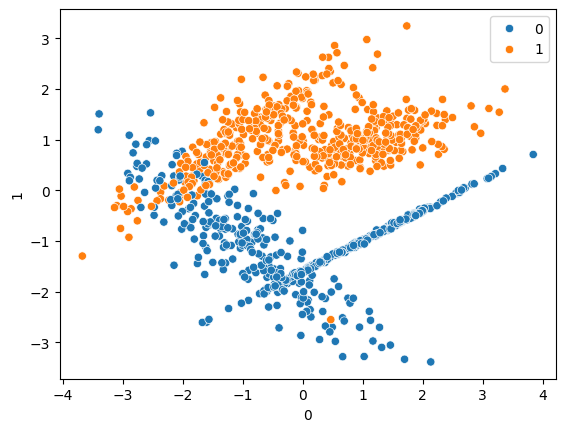

In [58]:
sns.scatterplot(x= pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue = y)

In [59]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30,random_state=30)

In [62]:
svc.fit(x_train,y_train)

SVC(kernel='linear')

In [63]:
y_pred = svc.predict(x_test)

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test,y_pred)
print(cr)
print(cm)
print("accuracy: ",acc)

              precision    recall  f1-score   support

           0       0.97      0.91      0.94       159
           1       0.90      0.96      0.93       141

    accuracy                           0.93       300
   macro avg       0.93      0.94      0.93       300
weighted avg       0.94      0.93      0.93       300

[[144  15]
 [  5 136]]
accuracy:  0.9333333333333333


In [65]:
rbf = SVC(kernel='rbf')
rbf.fit(x_train,y_train)
y_pred_rbf = rbf.predict(x_test)


In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
cr = classification_report(y_test, y_pred_rbf)
cm = confusion_matrix(y_test, y_pred_rbf)
acc = accuracy_score(y_test,y_pred_rbf)
print(cr)
print(cm)
print("accuracy: ",acc)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       159
           1       0.99      0.94      0.96       141

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

[[157   2]
 [  8 133]]
accuracy:  0.9666666666666667


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

poly = SVC(kernel='rbf')
poly.fit(x_train,y_train)
y_pred_poly = rbf.predict(x_test)
print(classification_report(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))
print(accuracy_score(y_test,y_pred_poly))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       159
           1       0.99      0.94      0.96       141

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

[[157   2]
 [  8 133]]
0.9666666666666667


In [69]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sig = SVC(kernel='sigmoid')
sig.fit(x_train,y_train)
y_pred_sig = rbf.predict(x_test)
print(classification_report(y_test, y_pred_sig))
print(confusion_matrix(y_test, y_pred_sig))
print(accuracy_score(y_test,y_pred_sig))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       159
           1       0.99      0.94      0.96       141

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

[[157   2]
 [  8 133]]
0.9666666666666667


In [76]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param = {
    'C' : [1,100,0.01],
    'gamma' : [1,100,0.1,0.001],
    'kernel' : ['linear', 'sigmoid', 'poly', 'rbf']
}
grid = GridSearchCV(estimator=SVC(), param_grid=param,cv=5, refit=True,n_jobs=-1)

In [77]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 100, 0.01], 'gamma': [1, 100, 0.1, 0.001],
                         'kernel': ['linear', 'sigmoid', 'poly', 'rbf']})

In [78]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [79]:
grid.best_score_

np.float64(0.9557142857142857)

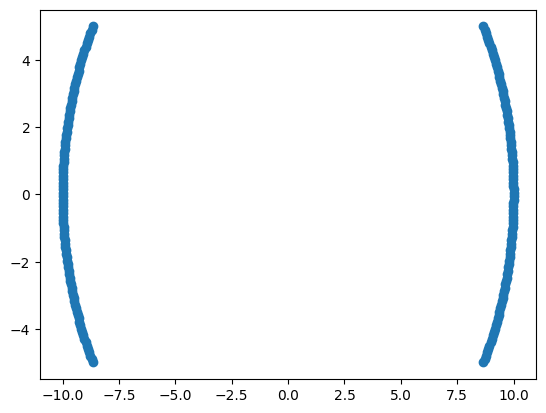

In [1]:
# SVM Kernels


import numpy as np
import matplotlib.pyplot as plt


#x and y coordinates to plot the outer circle data
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])
plt.scatter(y,x)

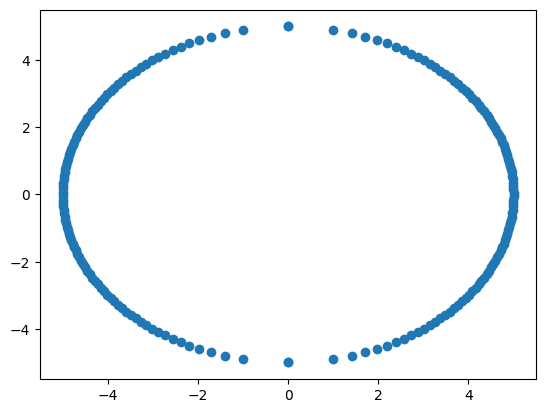

In [2]:
#x1 and y1 coordinates to plot inner circle data

x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])
plt.scatter(y1,x1)

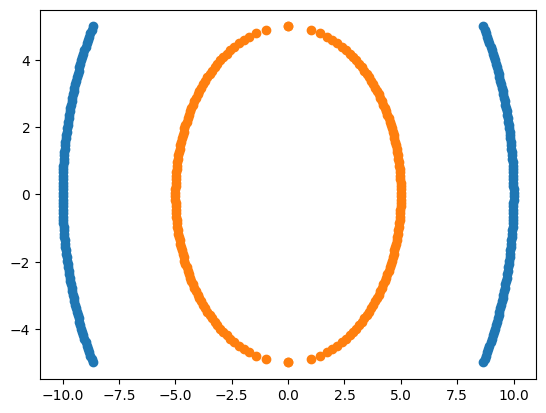

In [3]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [4]:
import numpy as np
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

In [5]:
import pandas as pd
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1,df2])
df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [6]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
y

0      0
1      0
2      0
3      0
4      0
      ..
195    1
196    1
197    1
198    1
199    1
Name: Y, Length: 400, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

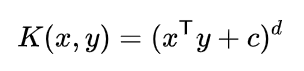

In [8]:
# We need to find components for the Polynomical Kernel
#X1,X2,X1_square,X2_square,X1*X2
df['X1_Square']= df['X1']**2
df['X2_Square']= df['X2']**2
df['X1*X2'] = (df['X1'] *df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [9]:
### Independent and Dependent features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [11]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',color='Y')
fig.show()

In [12]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',color='Y')
fig.show()

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="poly")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [26]:
# SVM for Regression
import seaborn as sns
df = sns.load_dataset('tips')

In [27]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [29]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [30]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [31]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [32]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [25]:
x = df.iloc[:,1:]
y = df.iloc[:,0]
x.columns

Index(['tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [34]:
x_train.head()

,tip,sex,smoker,day,time,size
115,3.50,1,0,Sun,Dinner,2
181,5.65,0,1,Sun,Dinner,2
225,2.50,1,1,Fri,Lunch,2
68,2.01,0,0,Sat,Dinner,2
104,4.08,1,0,Sat,Dinner,2


In [35]:
type(x_train)

pandas.core.frame.DataFrame

In [37]:
from sklearn.preprocessing import LabelEncoder
l1,l2,l3 = LabelEncoder(),LabelEncoder(),LabelEncoder()

In [39]:
x_train['sex']=l1.fit_transform(x_train['sex'])
x_train['smoker']=l2.fit_transform(x_train['smoker'])
x_train['time']=l3.fit_transform(x_train['time'])

In [40]:
x_test['sex'] = l1.transform(x_test['sex'])
x_test['smoker'] = l2.transform(x_test['smoker'])
x_test['time'] = l3.transform(x_test['time'])

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),[3])],remainder='passthrough')

In [48]:
import sys
import numpy as np
np.set_printoptions(threshold=sys.maxsize)

x_train = ct.fit_transform(x_train)

In [50]:
x_test = ct.transform(x_test)

In [51]:
x_test

array([[1.  , 0.  , 0.  , 3.18, 0.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 0.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 0.  , 0.  , 0.  , 4.  ],
       [1.  , 0.  , 0.  , 5.16, 0.  , 1.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 2.  , 1.  , 1.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 0.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 2.56, 0.  , 1.  , 1.  , 2.  ],
       [0.  , 0.  , 1.  , 2.52, 1.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 3.23, 0.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 0.  , 3.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 3.  , 0.  , 0.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 1.47, 0.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.5 , 1.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 0.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.83, 1.  , 0.  , 1.  , 1.  ],
       [0.  , 0.  , 1.  , 1.36, 1.  , 0.  , 1.  , 3.  ],
       [0.  , 0.  , 1.  , 4.  , 0.  , 1.  , 1.  , 3.  ],
       [0.  , 1.  , 0.  , 3.92,

In [52]:
#support vector regression

from sklearn.svm import SVR
svr = SVR()

In [53]:
svr.fit(x_train,y_train)

SVR()

In [54]:
y_pred = svr.predict(x_test)

In [55]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))


0.4980403670836009
4.462257656151341
39.30698454117902


In [58]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param = {
    'C' : [1,0.01],
    'gamma' : [1,100,0.1],
    'kernel' : ['linear', 'sigmoid', 'poly', 'rbf']
}
grid = GridSearchCV(estimator=SVR(), param_grid=param,cv=5, refit=True,verbose=3)

In [ ]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END .......C=1, gamma=1, kernel=linear;, score=0.618 total time=   0.0s
[CV 2/5] END .......C=1, gamma=1, kernel=linear;, score=0.664 total time=   0.0s
[CV 3/5] END .......C=1, gamma=1, kernel=linear;, score=0.371 total time=   0.0s
[CV 4/5] END .......C=1, gamma=1, kernel=linear;, score=0.671 total time=   0.0s
[CV 5/5] END .......C=1, gamma=1, kernel=linear;, score=0.221 total time=   0.0s
[CV 1/5] END .....C=1, gamma=1, kernel=sigmoid;, score=-0.162 total time=   0.0s
[CV 2/5] END .....C=1, gamma=1, kernel=sigmoid;, score=-0.038 total time=   0.0s
[CV 3/5] END .....C=1, gamma=1, kernel=sigmoid;, score=-0.032 total time=   0.0s
[CV 4/5] END .....C=1, gamma=1, kernel=sigmoid;, score=-0.036 total time=   0.0s
[CV 5/5] END .....C=1, gamma=1, kernel=sigmoid;, score=-0.165 total time=   0.0s
[CV 1/5] END ........C=1, gamma=1, kernel=poly;, score=-0.469 total time=   0.5s
[CV 2/5] END ........C=1, gamma=1, kernel=poly;

In [ ]:
grid.best_params_